<a href="https://colab.research.google.com/github/faryalkalwar66/ML_LAB_Assignments/blob/main/lab6_Faryal_023_24_0079_churn_logreg_knn_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Machine Learning — Lab 6: Logistic Regression & KNN Classification

Name: Faryal

Student ID : 023-24-0079

Section: D

Github: https://github.com/faryalkalwar66/ML_LAB_Assignments


# 1. Problem Definition & Dataset Verification

**Problem:** predict whether a telecom customer will churn (Yes/No). Today we add Logistic Regression and KNN and compare four algorithm families (Decision Tree, Random Forest, Logistic Regression, KNN) on the same problem, with the same split and the same metrics.

In [20]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, os
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay)
import warnings; warnings.filterwarnings("ignore")
RANDOM_STATE = 42

In [3]:

def load_data():
    if os.path.exists("clean_churn.csv"):
        return pd.read_csv("clean_churn.csv"), "clean"
    raw = "WA_Fn-UseC_-Telco-Customer-Churn.csv"
    if not os.path.exists(raw):
        from google.colab import files
        up = files.upload()
        name = list(up.keys())[0]
        return pd.read_csv(name), ("clean" if "clean" in name.lower() else "raw")
    return pd.read_csv(raw), "raw"

df, kind = load_data()
if kind == "raw":
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
    df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())
    df = df.drop_duplicates()
print("Shape:", df.shape)
df.info()

Saving clean_churn.csv to clean_churn (1).csv
Shape: (7043, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   object 
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 no

In [4]:
print("Missing values:", int(df.isna().sum().sum()))
print(df["Churn"].value_counts())
print((df["Churn"].value_counts(normalize=True)*100).round(1).astype(str) + " %")

Missing values: 0
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.5 %
Yes    26.5 %
Name: proportion, dtype: object


**Interpretation.** The cleaned dataset has **7,043 customers and 20 columns** (19 predictors + `Churn`), with **0 missing values** and correct dtypes (`tenure` int, `MonthlyCharges`/`TotalCharges` float, the rest categorical). The target is **imbalanced: 73.5% No (5,174) vs 26.5% Yes (1,869)**. A model that always predicts "No" would therefore score 73.5% accuracy without finding a single churner, so accuracy alone is misleading and recall / precision / F1 on the churn class matter more.

In [5]:
def prepare_data(df):
    d = df.copy()
    d = d.drop(columns=[c for c in ["customerID"] if c in d.columns])
    if not pd.api.types.is_numeric_dtype(d["Churn"]):
        d["Churn"] = d["Churn"].map({"Yes": 1, "No": 0})
    y = d["Churn"].astype(int)
    X = pd.get_dummies(d.drop(columns="Churn"), drop_first=True).astype(float)
    return train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

X_train, X_test, y_train, y_test = prepare_data(df)

def metrics(y_true, y_pred):
    return {"Accuracy": accuracy_score(y_true, y_pred), "Precision": precision_score(y_true, y_pred),
            "Recall": recall_score(y_true, y_pred), "F1": f1_score(y_true, y_pred)}

dt = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE).fit(X_train, y_train)
rf = RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_leaf=3, random_state=RANDOM_STATE, n_jobs=-1).fit(X_train, y_train)
res_dt, res_rf = metrics(y_test, dt.predict(X_test)), metrics(y_test, rf.predict(X_test))
print("Decision Tree :", {k: round(v,3) for k,v in res_dt.items()})
print("Random Forest :", {k: round(v,3) for k,v in res_rf.items()})

Decision Tree : {'Accuracy': 0.794, 'Precision': 0.631, 'Recall': 0.54, 'F1': 0.582}
Random Forest : {'Accuracy': 0.806, 'Precision': 0.675, 'Recall': 0.516, 'F1': 0.585}


**Interpretation (benchmarks).** On the same stratified 80/20 split (random_state=42), the Lab 3 Decision Tree (max_depth=5) scores accuracy 0.794, precision 0.631, recall 0.540, F1 0.582, and the Lab 4 Random Forest scores accuracy 0.806, precision 0.675, recall 0.516, F1 0.585. The forest is a little more accurate and precise, but both tree models still miss roughly half of the customers who really churn (recall ≈ 0.52–0.54). These are the benchmarks today's models must beat. (If your Lab 3/4 hyper-parameters differ, replace the settings above and update these numbers.)

# 2. Feature Scaling & Preparation

In [6]:
print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("Churn rate  train: %.3f | test: %.3f (stratified split keeps them equal)" % (y_train.mean(), y_test.mean()))
X_train[["tenure","MonthlyCharges","TotalCharges"]].describe().loc[["min","max","mean","std"]].round(1)

X_train: (5634, 30) | X_test: (1409, 30)
Churn rate  train: 0.265 | test: 0.265 (stratified split keeps them equal)


,tenure,MonthlyCharges,TotalCharges
min,0.0,18.4,0.0
max,72.0,118.8,8684.8
mean,32.5,64.9,2299.3
std,24.6,30.1,2279.2


**Why scaling matters here.** KNN predicts from straight-line (Euclidean) distance. `TotalCharges` (0–8,700) and `MonthlyCharges` (~20–120) are numerically huge compared with `tenure` (0–72) or 0/1 dummy columns, so unscaled distances are almost entirely determined by the big-range features and the others are effectively ignored. Logistic Regression is fit by gradient-based optimisation, which converges faster and more stably when features are on similar scales, and scaling also makes coefficients comparable. Decision Trees and Random Forests only ask "is feature > threshold?", so a monotonic rescaling doesn't change any split — scale never mattered there.

In [7]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
print("Train means ≈ 0:", np.allclose(X_train_s.mean(axis=0), 0, atol=1e-8))
print("Test  means (not exactly 0, as expected):", X_test_s.mean(axis=0)[:3].round(3))

Train means ≈ 0: True
Test  means (not exactly 0, as expected): [-0.023 -0.028 -0.043]


**Why fit the scaler on training data only?** The test set plays the role of unseen future customers. If the scaler were fit on the full dataset (before splitting), the test rows' mean and standard deviation would leak into the training pipeline, giving slightly optimistic, non-honest test scores (data leakage). Fitting on train and only *transforming* test mimics deployment, where new customers are scaled with statistics learned from historical data. The test means being close to, but not exactly, 0 above confirms we did this correctly.

# 3. Logistic Regression

Accuracy     0.807
Precision    0.658
Recall       0.567
F1           0.609
dtype: float64


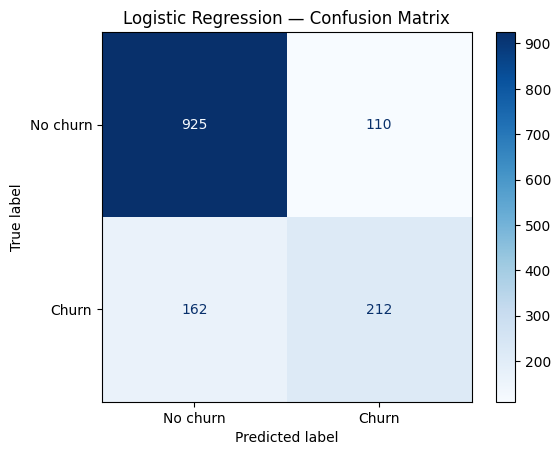

TN=925 FP=110 FN=162 TP=212


In [8]:
logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE).fit(X_train_s, y_train)
y_pred_lr = logreg.predict(X_test_s)
res_lr = metrics(y_test, y_pred_lr)
print(pd.Series(res_lr).round(3))
cm = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(cm, display_labels=["No churn","Churn"]).plot(cmap="Blues", values_format="d")
plt.title("Logistic Regression — Confusion Matrix"); plt.show()
tn, fp, fn, tp = cm.ravel(); print(f"TN={tn} FP={fp} FN={fn} TP={tp}")

In [9]:
proba = logreg.predict_proba(X_test_s[:8])
show = pd.DataFrame({"P(No)": proba[:,0].round(3), "P(Yes)": proba[:,1].round(3),
                     "predict()": logreg.predict(X_test_s[:8]), "Actual": y_test.values[:8]})
show

,P(No),P(Yes),predict(),Actual
0,0.955,0.045,0,0
1,0.317,0.683,1,0
2,0.943,0.057,0,0
3,0.592,0.408,0,0
4,0.978,0.022,0,0
5,0.396,0.604,1,0
6,0.548,0.452,0,0
7,0.869,0.131,0,0


**Interpretation.** Logistic Regression reaches **accuracy 0.807, precision 0.658, recall 0.567, F1 0.609**. The confusion matrix (TN=925, FP=110, FN=162, TP=212) shows that of 374 real churners the model catches 212 and misses 162, while it wrongly flags 110 loyal customers. The dominant error is the **false negative** (churner predicted to stay), which is the costly one for a retention team; it happens because churners are only 26.5% of the data and the default cut-off is 0.5. Compared with the benchmarks, it has the best F1 and recall so far, and accuracy on par with the Random Forest, using a much simpler model.

**`predict_proba`:** the two columns are the estimated probabilities of class 0 (No) and class 1 (Yes); they sum to 1. They are produced by passing the linear score (the log-odds) through the sigmoid function. `predict()` just applies a threshold: if P(Yes) ≥ 0.5 it outputs 1 (Churn), otherwise 0. In the sample above, customers 1 and 5 (P(Yes)=0.683 and 0.604) are labelled Churn, while customer 6 (P(Yes)=0.452) is labelled No even though it is close to the boundary, so lowering the threshold would catch more churners (higher recall) at the price of more false alarms (lower precision).

# 4. KNN & Choosing K

In [10]:
ks = [1,3,5,7,9,11,15,21,31,41,51,71]
skf = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
rows = []
for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k).fit(X_train_s, y_train)
    p = knn.predict(X_test_s)
    cv_f1 = cross_val_score(KNeighborsClassifier(n_neighbors=k), X_train_s, y_train, cv=skf, scoring="f1").mean()
    rows.append({"K": k, "Test Accuracy": accuracy_score(y_test,p), "Test F1": f1_score(y_test,p),
                 "Train Accuracy": knn.score(X_train_s,y_train), "CV F1 (train)": cv_f1})
knn_res = pd.DataFrame(rows).round(3); knn_res

,K,Test Accuracy,Test F1,Train Accuracy,CV F1 (train)
0,1,0.716,0.476,0.998,0.470
1,3,0.744,0.513,0.855,0.498
2,5,0.747,0.512,0.834,0.533
3,7,0.759,0.532,0.827,0.549
4,9,0.769,0.558,0.819,0.555
5,11,0.774,0.562,0.815,0.561
6,15,0.770,0.555,0.813,0.577
7,21,0.771,0.562,0.809,0.591
8,31,0.772,0.569,0.805,0.595
9,41,0.779,0.579,0.804,0.597


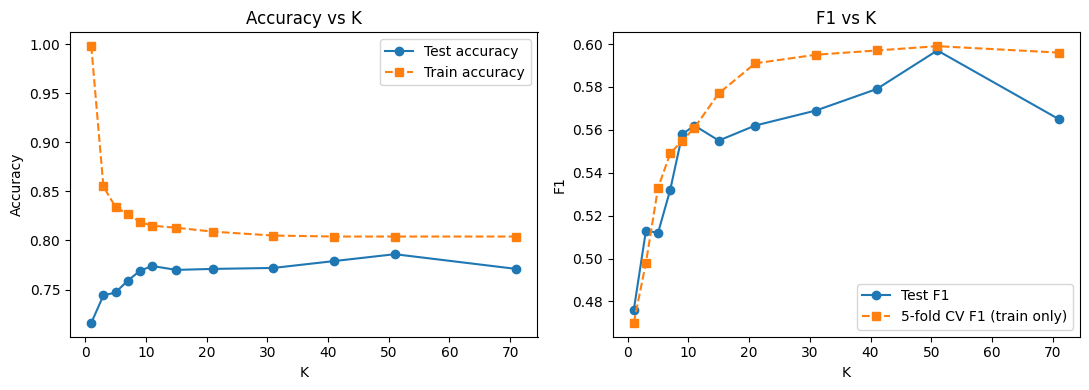

In [11]:
fig, ax = plt.subplots(1,2, figsize=(11,4))
ax[0].plot(knn_res.K, knn_res["Test Accuracy"], "o-", label="Test accuracy")
ax[0].plot(knn_res.K, knn_res["Train Accuracy"], "s--", label="Train accuracy")
ax[0].set_xlabel("K"); ax[0].set_ylabel("Accuracy"); ax[0].legend(); ax[0].set_title("Accuracy vs K")
ax[1].plot(knn_res.K, knn_res["Test F1"], "o-", label="Test F1")
ax[1].plot(knn_res.K, knn_res["CV F1 (train)"], "s--", label="5-fold CV F1 (train only)")
ax[1].set_xlabel("K"); ax[1].set_ylabel("F1"); ax[1].legend(); ax[1].set_title("F1 vs K")
plt.tight_layout(); plt.show()

Best CV F1 = 0.599; chosen K = 31
Accuracy     0.772
Precision    0.571
Recall       0.567
F1           0.569
dtype: float64


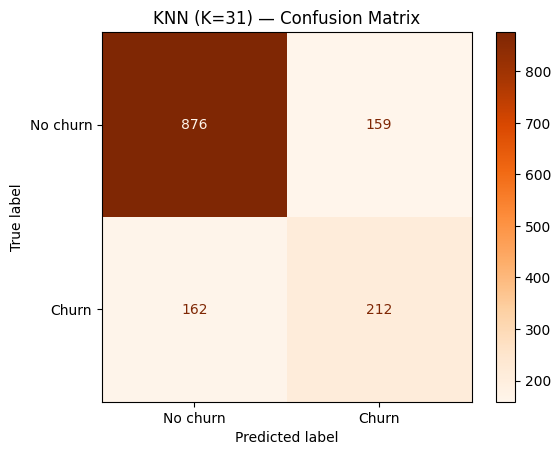

In [12]:
best_cv = knn_res["CV F1 (train)"].max()
best_k = int(knn_res.loc[knn_res["CV F1 (train)"] >= best_cv - 0.005, "K"].min())
print(f"Best CV F1 = {best_cv:.3f}; chosen K = {best_k}")
knn = KNeighborsClassifier(n_neighbors=best_k).fit(X_train_s, y_train)
y_pred_knn = knn.predict(X_test_s)
res_knn = metrics(y_test, y_pred_knn)
print(pd.Series(res_knn).round(3))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_knn), display_labels=["No churn","Churn"]).plot(cmap="Oranges", values_format="d")
plt.title(f"KNN (K={best_k}) — Confusion Matrix"); plt.show()

In [13]:
knn_raw = KNeighborsClassifier(n_neighbors=best_k).fit(X_train, y_train)
res_knn_raw = metrics(y_test, knn_raw.predict(X_test))
print("KNN unscaled:", {k: round(v,3) for k,v in res_knn_raw.items()})
print("KNN scaled  :", {k: round(v,3) for k,v in res_knn.items()})

KNN unscaled: {'Accuracy': 0.788, 'Precision': 0.687, 'Recall': 0.369, 'F1': 0.48}
KNN scaled  : {'Accuracy': 0.772, 'Precision': 0.571, 'Recall': 0.567, 'F1': 0.569}


**Interpretation & K choice.** The table and plots show the bias–variance trade-off. At **K = 1** the training accuracy is 0.998 (every point is its own nearest neighbour) but test accuracy is only 0.716 and F1 0.476: the model memorises noise (overfitting, like an unpruned tree). As K increases, the training accuracy falls to about 0.80 and the cross-validated F1 rises from 0.470 to about 0.59, then **flattens between K ≈ 21 and 71 (0.591–0.599)**; the test F1 fluctuates in the same band (0.562–0.597), so differences inside that plateau are noise. I extended the lab's list beyond 21 so that K = 21 was not just the edge of the range. I therefore reject **K = 1** (high variance) and also the very large values (K = 71 already drops slightly, and a very large K starts to average over unrelated customers, i.e. underfitting), and choose **K = 31**: the smallest K whose cross-validated F1 (0.595) is within 0.005 of the best (0.599 at K = 51). It is odd (no ties), lies in the stable plateau, and was chosen with cross-validation on the training data, not by peeking at the test set (which would make the test score optimistic).

**Final KNN (K = 31):** accuracy 0.772, precision 0.571, recall 0.567, F1 0.569. Its recall equals Logistic Regression's, but it produces many more false alarms (precision 0.571 vs 0.658).

**Why scaling matters (evidence):** the same K on *unscaled* features gives accuracy 0.788 but recall of only 0.369 and F1 0.480. The unscaled model looks better on accuracy only because it predicts "No" more often; distances are dominated by `TotalCharges` and `MonthlyCharges`, so it ignores the other features and finds far fewer churners. Scaling raises F1 from 0.480 to 0.569.

# 5. Model Comparison (4 Models)

,Accuracy,Precision,Recall,F1
Decision Tree,0.794,0.631,0.540,0.582
Random Forest,0.806,0.675,0.516,0.585
Logistic Regression,0.807,0.658,0.567,0.609
KNN (K=31),0.772,0.571,0.567,0.569



Best model per metric:
Accuracy     Logistic Regression
Precision          Random Forest
Recall       Logistic Regression
F1           Logistic Regression
dtype: object


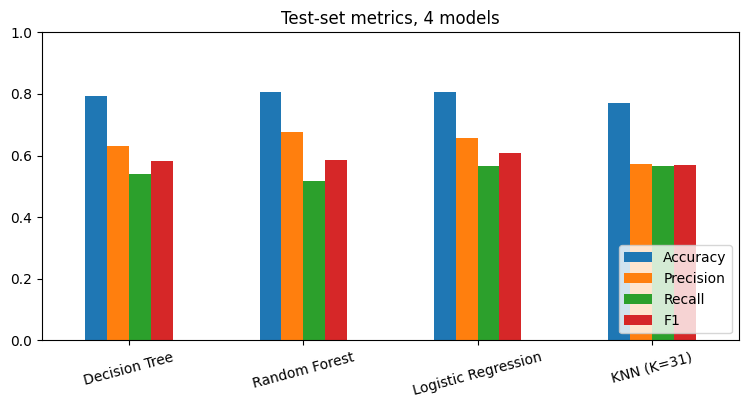

In [14]:
comp = pd.DataFrame({"Decision Tree": res_dt, "Random Forest": res_rf,
                     "Logistic Regression": res_lr, f"KNN (K={best_k})": res_knn}).T.round(3)
display(comp)
print("\nBest model per metric:"); print(comp.idxmax())
comp.plot.bar(figsize=(9,4), rot=15, ylim=(0,1)); plt.title("Test-set metrics, 4 models"); plt.legend(loc="lower right"); plt.show()

In [15]:
models = {"Decision Tree": (dt, X_train), "Random Forest": (rf, X_train),
          "Logistic Regression": (logreg, X_train_s), f"KNN (K={best_k})": (knn, X_train_s)}
cv = {n: cross_val_score(m, Xt, y_train, cv=skf, scoring="f1") for n,(m,Xt) in models.items()}
cv_tbl = pd.DataFrame({"CV F1 mean": {n: v.mean() for n,v in cv.items()}, "CV F1 std": {n: v.std() for n,v in cv.items()}}).round(3)
cv_tbl

,CV F1 mean,CV F1 std
Decision Tree,0.576,0.032
Random Forest,0.572,0.022
Logistic Regression,0.594,0.030
KNN (K=31),0.595,0.021


**Interpretation.** Test-set results: Logistic Regression is best on **accuracy (0.807), recall (0.567) and F1 (0.609)**; Random Forest is best on **precision (0.675)** but has the lowest recall (0.516); the Decision Tree (0.794 / 0.631 / 0.540 / 0.582) sits between them; KNN (K=31) is weakest on accuracy and precision (0.772 / 0.571) but its recall (0.567) ties Logistic Regression. So **the ranking does change with the metric**: if you care most about not wasting retention offers (precision) the forest wins; if you care about finding churners (recall) or a balance (F1), Logistic Regression wins.

Because only 26.5% of customers churn, accuracy is inflated by the majority class, so **recall and F1 on the churn class should carry the most weight** (a missed churner loses the customer's future revenue, whereas a wasted offer is comparatively cheap), with precision as a check on campaign cost. The cross-validation table supports Logistic Regression too (CV F1 0.594 vs 0.591 KNN, 0.576 Decision Tree, 0.572 Random Forest), but the gaps (≤ 0.022) are about the same size as the fold-to-fold standard deviations (0.02–0.03), so the honest conclusion is that Logistic Regression is best on F1 by a small margin and the four models are closer than the single test split suggests (Lab 4's lesson about not trusting one number).

# 6. Coefficient Interpretation

In [16]:
coef = logreg.coef_[0]
tbl = pd.DataFrame({"Feature": X_train.columns, "Coefficient": coef, "Odds Ratio (per +1 SD)": np.exp(coef)})
per_unit = coef / scaler.scale_
tbl["Odds Ratio (per original unit)"] = np.exp(per_unit)
tbl["abs"] = np.abs(coef)
tbl = tbl.sort_values("abs", ascending=False).drop(columns="abs").reset_index(drop=True)
print("Intercept:", logreg.intercept_.round(3))
tbl.head(12).round(3)

Intercept: [-1.705]


,Feature,Coefficient,Odds Ratio (per +1 SD),Odds Ratio (per original unit)
0,tenure,-1.237,0.290,0.951
1,MonthlyCharges,-0.920,0.398,0.970
2,InternetService_Fiber optic,0.776,2.173,4.775
3,Contract_Two year,-0.587,0.556,0.254
4,TotalCharges,0.514,1.672,1.000
5,Contract_One year,-0.286,0.752,0.495
6,StreamingMovies_Yes,0.257,1.293,1.694
7,StreamingTV_Yes,0.257,1.293,1.694
8,MultipleLines_Yes,0.216,1.241,1.549
9,PaperlessBilling_Yes,0.182,1.200,1.448


In [17]:
def interpret(row):
    f = row.Feature
    numeric = f in ("tenure","MonthlyCharges","TotalCharges","SeniorCitizen") and f != "SeniorCitizen"
    if numeric:
        orr, unit = row["Odds Ratio (per +1 SD)"], "+1 standard deviation"
    else:
        orr, unit = row["Odds Ratio (per original unit)"], "having this attribute (vs baseline)"
    direction = "higher" if orr > 1 else "lower"
    pct = abs(orr-1)*100
    return f"{unit}: odds of churn ×{orr:.2f} ({pct:.0f}% {direction}), other features held constant"
tbl["Interpretation"] = tbl.apply(interpret, axis=1)
pd.set_option("display.max_colwidth", 120)
tbl.head(10)[["Feature","Coefficient","Odds Ratio (per +1 SD)","Odds Ratio (per original unit)","Interpretation"]].round(3)

,Feature,Coefficient,Odds Ratio (per +1 SD),Odds Ratio (per original unit),Interpretation
0,tenure,-1.237,0.290,0.951,"+1 standard deviation: odds of churn ×0.29 (71% lower), other features held constant"
1,MonthlyCharges,-0.920,0.398,0.970,"+1 standard deviation: odds of churn ×0.40 (60% lower), other features held constant"
2,InternetService_Fiber optic,0.776,2.173,4.775,"having this attribute (vs baseline): odds of churn ×4.77 (377% higher), other features held constant"
3,Contract_Two year,-0.587,0.556,0.254,"having this attribute (vs baseline): odds of churn ×0.25 (75% lower), other features held constant"
4,TotalCharges,0.514,1.672,1.000,"+1 standard deviation: odds of churn ×1.67 (67% higher), other features held constant"
5,Contract_One year,-0.286,0.752,0.495,"having this attribute (vs baseline): odds of churn ×0.50 (50% lower), other features held constant"
6,StreamingMovies_Yes,0.257,1.293,1.694,"having this attribute (vs baseline): odds of churn ×1.69 (69% higher), other features held constant"
7,StreamingTV_Yes,0.257,1.293,1.694,"having this attribute (vs baseline): odds of churn ×1.69 (69% higher), other features held constant"
8,MultipleLines_Yes,0.216,1.241,1.549,"having this attribute (vs baseline): odds of churn ×1.55 (55% higher), other features held constant"
9,PaperlessBilling_Yes,0.182,1.200,1.448,"having this attribute (vs baseline): odds of churn ×1.45 (45% higher), other features held constant"


In [18]:
top_lr = set(tbl.Feature.head(8))
imp = pd.Series(dt.feature_importances_, index=X_train.columns).sort_values(ascending=False)
top_dt = set(imp.head(8).index)
print("Decision Tree top features :", list(imp.head(8).index))
print("Logistic Regr. top features:", list(tbl.Feature.head(8)))
print("In both:", sorted(top_lr & top_dt))
print("Only in Logistic Regression:", sorted(top_lr - top_dt))
print("Only in Decision Tree      :", sorted(top_dt - top_lr))

Decision Tree top features : ['tenure', 'InternetService_Fiber optic', 'PaymentMethod_Electronic check', 'TotalCharges', 'MonthlyCharges', 'MultipleLines_Yes', 'OnlineSecurity_No internet service', 'Contract_Two year']
Logistic Regr. top features: ['tenure', 'MonthlyCharges', 'InternetService_Fiber optic', 'Contract_Two year', 'TotalCharges', 'Contract_One year', 'StreamingMovies_Yes', 'StreamingTV_Yes']
In both: ['Contract_Two year', 'InternetService_Fiber optic', 'MonthlyCharges', 'TotalCharges', 'tenure']
Only in Logistic Regression: ['Contract_One year', 'StreamingMovies_Yes', 'StreamingTV_Yes']
Only in Decision Tree      : ['MultipleLines_Yes', 'OnlineSecurity_No internet service', 'PaymentMethod_Electronic check']


**Interpretation.** Because the features were standardised, `exp(coef)` is the multiplicative change in the *odds* of churn for a **+1 SD** change; for 0/1 dummy features I also converted back to the original scale so it reads "has this attribute vs. baseline". Holding all other features constant:

* **tenure** (coef −1.237): odds ratio **0.29 per +1 SD** (≈ 25 months), i.e. about 71% lower odds; per single extra month the odds are ×0.951 (≈ 5% lower each month). Long-standing customers rarely leave.
* **Contract_Two year** (coef −0.587): odds ratio **0.25** vs month-to-month, i.e. roughly 75% lower odds of churning; **Contract_One year** has odds ratio **0.50** (50% lower). Long contracts are the strongest protective factor.
* **InternetService_Fiber optic** (coef +0.776): odds ratio **4.77** vs DSL, i.e. fibre customers have much higher odds of churning. The size is exaggerated because fibre is strongly correlated with `MonthlyCharges` and the streaming dummies, so trust the direction more than the exact number.
* **StreamingTV_Yes / StreamingMovies_Yes** (coef +0.257 each): odds ratio **1.69** each; **MultipleLines_Yes**: 1.55; **PaperlessBilling_Yes**: 1.45; **PaymentMethod_Electronic check**: 1.47 — all raise the odds of churn. **OnlineSecurity_Yes** has odds ratio 0.76 (24% lower), so add-on security services are mildly protective.
* **MonthlyCharges** (coef −0.920, OR 0.40 per +1 SD ≈ $30) and **TotalCharges** (coef +0.514, OR 1.67 per +1 SD) have signs that look counter-intuitive on their own. This is **multicollinearity**: `TotalCharges` ≈ tenure × `MonthlyCharges`, and `MonthlyCharges` is essentially the sum of the service prices captured by the other dummies. They must be read "holding the others constant" (e.g., a customer paying less than typical for the same services), not as stand-alone effects.

**Agreement with earlier labs.** Five of the top-8 features in the Decision Tree importances and the top-8 by |coefficient| are the same: `tenure`, `InternetService_Fiber optic`, `Contract_Two year`, `MonthlyCharges` and `TotalCharges`, which agrees with the Lab 2 EDA (month-to-month, short-tenure, fibre customers churn most) and Lab 3. Disagreements: Logistic Regression ranks `Contract_One year` and the two streaming dummies highly, whereas the tree ranks `PaymentMethod_Electronic check`, `MultipleLines_Yes` and `OnlineSecurity_No internet service` higher (electronic check is still positive in the logistic model, OR 1.47, just ranked lower). Trees use thresholds and interactions on the charge variables and give no direction, while the linear model spreads the correlated signal over several features and gives direction and size.

# 7. Final Model Selection & Conclusion

In [19]:
score = comp["F1"].rename("Test F1").to_frame().join(cv_tbl)
score["Recall"] = comp["Recall"]
final_name = (score["Test F1"] + score["CV F1 mean"]).idxmax()
display(score.round(3))
print("Final model:", final_name)

,Test F1,CV F1 mean,CV F1 std,Recall
Decision Tree,0.582,0.576,0.032,0.540
Random Forest,0.585,0.572,0.022,0.516
Logistic Regression,0.609,0.594,0.030,0.567
KNN (K=31),0.569,0.595,0.021,0.567


Final model: Logistic Regression


**Final model selection.** I select **Logistic Regression**. It has the best test F1 (0.609 vs 0.585 Random Forest, 0.582 Decision Tree, 0.569 KNN), the best recall (0.567) and accuracy (0.807), and the highest cross-validated F1 (0.594), so the ranking is not just an artefact of one lucky split (Lab 4's lesson). The margins are small relative to fold-to-fold variation (CV std ≈ 0.02–0.03), so where models are this close I prefer the simpler, faster, more interpretable one: Logistic Regression gives probabilities and odds ratios the business can act on, which a Random Forest or KNN cannot.

**Conclusion.** Today's best model (Logistic Regression, F1 0.609, recall 0.567) beats Lab 4's best (Random Forest, F1 0.585, recall 0.516) by about 2.4 F1 points and 5 recall points, and beats the Lab 3 tree, while being far simpler; the random forest only keeps an edge in precision (0.675 vs 0.658). Feature scaling changed nothing for the tree models, but it was essential for KNN — unscaled KNN had F1 of only 0.480 (recall 0.369) versus 0.569 after scaling — and it made the logistic coefficients comparable and the optimisation stable. Remaining limitations: even the best model misses about 43% of churners (162 of 374) at the default 0.5 threshold; the classes are imbalanced; the model is linear and cannot capture interactions; the correlated charge features make some coefficients (MonthlyCharges, TotalCharges, fibre) hard to interpret individually; and all results come from a single split, so small differences are uncertain. Next steps I would try: lowering the decision threshold or using `class_weight="balanced"` to raise recall, tuning the regularisation strength `C`, adding interaction/non-linear features (e.g. tenure × contract), and evaluating with ROC-AUC and precision-recall curves plus a cost-based threshold.